In [4]:
import polars as pl

rna_seq_sources = ['doi:10.1016/j.cell.2015.07.061', 'doi:10.1158/1078-0432.CCR-18-0720', 'doi:10.1172/JCI78954DS1']

gex = pl.read_csv('../dataset/original/gene_expressions.csv')
# gex = gex.filter(
#     (pl.col('temporality') == 'pre treatment') & (pl.col('source').is_in(rna_seq_sources))
#     )
gex

id,creation_datetime,patientID,sample_id,HGNC,GeneID,description,value,temporality,source
i64,str,str,str,str,str,str,f64,str,str
1,"""2025-04-23 23:02:05.503260""","""LM_1""","""LMSAM_1""","""BRAF""",null,null,7.60798,"""pre treatment""","""doi:10.3390/cancers11081203"""
2,"""2025-04-23 23:02:05.503285""","""LM_1""","""LMSAM_1""","""RAF1""",null,null,16.095204,"""pre treatment""","""doi:10.3390/cancers11081203"""
3,"""2025-04-23 23:02:05.503298""","""LM_1""","""LMSAM_1""","""ARAF""",null,null,4.1515,"""pre treatment""","""doi:10.3390/cancers11081203"""
4,"""2025-04-23 23:02:05.503312""","""LM_1""","""LMSAM_1""","""PDGFRB""",null,null,1.199885,"""pre treatment""","""doi:10.3390/cancers11081203"""
5,"""2025-04-23 23:02:05.503324""","""LM_1""","""LMSAM_1""","""IGF1R""",null,null,5.47246,"""pre treatment""","""doi:10.3390/cancers11081203"""
…,…,…,…,…,…,…,…,…,…
8641387,"""2025-04-24 00:42:16.629746""","""HL_Shi-40""","""Pt21-DP2""","""ZYG11A""",null,null,0.019542,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
8641388,"""2025-04-24 00:42:16.629757""","""HL_Shi-40""","""Pt21-DP2""","""ZYG11B""",null,null,4.04421,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
8641389,"""2025-04-24 00:42:16.629768""","""HL_Shi-40""","""Pt21-DP2""","""ZYX""",null,null,85.7967,"""progression""","""doi:10.1016/j.cell.2015.07.061"""


Using HGNC column: HGNC
shape: (6, 4)
┌─────────────────────────────────┬─────────────────┬────────────────┬──────────────┐
│ source                          ┆ unique_patients ┆ unique_samples ┆ unique_genes │
│ ---                             ┆ ---             ┆ ---            ┆ ---          │
│ str                             ┆ u32             ┆ u32            ┆ u32          │
╞═════════════════════════════════╪═════════════════╪════════════════╪══════════════╡
│ doi:10.1016/j.cell.2015.07.061  ┆ 13              ┆ 44             ┆ 25268        │
│ doi:10.1038/ncomms6694          ┆ 10              ┆ 50             ┆ 31332        │
│ doi:10.1158/1078-0432.CCR-13-3… ┆ 24              ┆ 80             ┆ 31332        │
│ doi:10.1158/1078-0432.CCR-18-0… ┆ 70              ┆ 72             ┆ 27853        │
│ doi:10.1172/JCI78954DS1         ┆ 23              ┆ 39             ┆ 30961        │
│ doi:10.3390/cancers11081203     ┆ 20              ┆ 20             ┆ 29           │
└───────────────

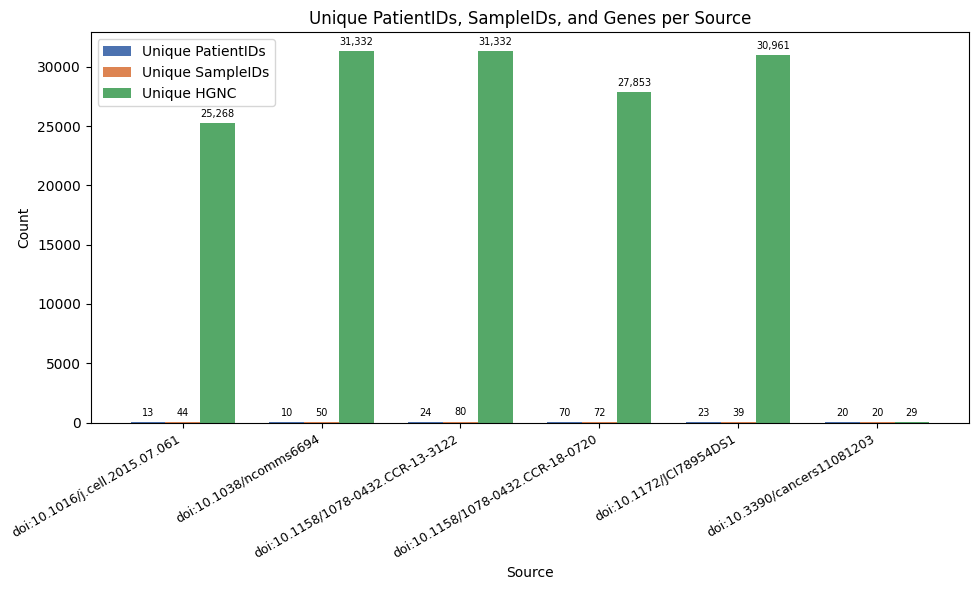

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Detect HGNC column (may be named 'HGNC', 'HGNC_symbol', 'gene', etc.)
hgnc_col = next((c for c in gex.columns if 'hgnc' in c.lower() or 'gene' in c.lower()), None)
print(f"Using HGNC column: {hgnc_col}")

# Compute unique counts per source
stats = gex.group_by("source").agg([
    pl.col("patientID").n_unique().alias("unique_patients"),
    pl.col("sample_id").n_unique().alias("unique_samples"),
    pl.col(hgnc_col).n_unique().alias("unique_genes"),
]).sort("source")

print(stats)

# Plot
sources = stats["source"].to_list()
x = np.arange(len(sources))
width = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(sources) * 1.5), 6))

bars1 = ax.bar(x - width, stats["unique_patients"].to_list(), width, label="Unique PatientIDs", color="#4C72B0")
bars2 = ax.bar(x,          stats["unique_samples"].to_list(),  width, label="Unique SampleIDs",  color="#DD8452")
bars3 = ax.bar(x + width,  stats["unique_genes"].to_list(),    width, label=f"Unique {hgnc_col}", color="#55A868")

ax.set_xlabel("Source")
ax.set_ylabel("Count")
ax.set_title("Unique PatientIDs, SampleIDs, and Genes per Source")
ax.set_xticks(x)
ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=9)
ax.legend()

for bars in (bars1, bars2, bars3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:,}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

In [6]:
gex.null_count()

id,creation_datetime,patientID,sample_id,HGNC,GeneID,description,value,temporality,source
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,92181,0,207000,6429047,4568231,0,95655,0
